In [ ]:
'''DATA 7703 Final Project Report
(Semester 2, 2025)





Discovering Research Topics and Temporal Trends in arXiv Papers Using Machine Learning








Group 29

Navaneetha Krishnan Shanmugam Pooranananthan (49102985)
Aslam Packir Kadar Mydeen (49405314)
Yuvaraja Murugan (48870465)
Flora Taheri (47340699)
Deepak Chakkungal Divakaran (49073151)'''


In [ ]:
import sys, sklearn, bertopic, hdbscan, pkg_resources
import os
import json
import pandas as pd
import random
import re
import unicodedata
import html
from datetime import datetime
from langdetect import detect, DetectorFactory
import csv
import re, html, unicodedata, json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import os, json, time, numpy as np, pandas as pd
from umap import UMAP
import hdbscan
import numpy as np, pandas as pd
from IPython.display import display
from bertopic.representation import KeyBERTInspired
from scipy.stats import spearmanr
import pandas as pd, numpy as np

In [31]:

print("Python:", sys.executable) 
print("sklearn:", sklearn.__version__)
print("bertopic:", bertopic.__version__)
print("hdbscan:", pkg_resources.get_distribution("hdbscan").version)


Python: D:\Anaconda\envs\arxivtopics\python.exe
sklearn: 1.4.2
bertopic: 0.16.0
hdbscan: 0.8.38.post1


In [1]:

os.environ["OMP_NUM_THREADS"]="4"
os.environ["OPENBLAS_NUM_THREADS"]="4"
os.environ["MKL_NUM_THREADS"]="4"
os.environ["VECLIB_MAXIMUM_THREADS"]="4"
os.environ["NUMEXPR_NUM_THREADS"]="4"


In [3]:

file="C://Users//Admin'//Downloads//arxiv-metadata-oai-snapshot.json"



In [5]:
with open(file,"r",encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i < 3:
            record= json.loads(line)
            print(json.dumps(record,indent=2))
        else:
            break

{
  "id": "0704.0001",
  "submitter": "Pavel Nadolsky",
  "authors": "C. Bal\\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan",
  "title": "Calculation of prompt diphoton production cross sections at Tevatron and\n  LHC energies",
  "comments": "37 pages, 15 figures; published version",
  "journal-ref": "Phys.Rev.D76:013009,2007",
  "doi": "10.1103/PhysRevD.76.013009",
  "report-no": "ANL-HEP-PR-07-12",
  "categories": "hep-ph",
  "license": null,
  "abstract": "  A fully differential calculation in perturbative quantum chromodynamics is\npresented for the production of massive photon pairs at hadron colliders. All\nnext-to-leading order perturbative contributions from quark-antiquark,\ngluon-(anti)quark, and gluon-gluon subprocesses are included, as well as\nall-orders resummation of initial-state gluon radiation valid at\nnext-to-next-to-leading logarithmic accuracy. The region of phase space is\nspecified in which the calculation is most reliable. Good agreement is\ndemonstrated with

In [7]:
keys=list(record.keys())
print("columns:", keys)

columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']


In [9]:
with open(file, "r", encoding="utf-8") as f:
    total_lines = sum(1 for _ in f)
print(f"Total records in the dataset: {total_lines}")

Total records in the dataset: 2828998


In [11]:
sample_size = 10000
sample = []

with open(file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if random.random() < sample_size / 2828998:  # ~2.6M records
            data = json.loads(line)
            if data.get("title") and data.get("abstract"):
                sample.append({
                    "id": data.get("id"),
                    "title": data.get("title"),
                    "abstract": data.get("abstract"),
                    "categories": data.get("categories"),
                    "year": data.get("update_date", "")[:4]
                })

print(f"Sampled {len(sample)} records.")
df = pd.DataFrame(sample)
print(df.info())
print(df.head())

Sampled 9954 records.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          9954 non-null   object
 1   title       9954 non-null   object
 2   abstract    9954 non-null   object
 3   categories  9954 non-null   object
 4   year        9954 non-null   object
dtypes: object(5)
memory usage: 389.0+ KB
None
          id                                              title  \
0  0704.0399    Hawking radiation of linear dilaton black holes   
1  0704.0456   Particle propagation in cosmological backgrounds   
2  0704.0507  E_6 and the bipartite entanglement of three qu...   
3  0704.0607  Plasmon Amplification through Stimulated Emiss...   
4  0704.0642     Direct photons and dileptons via color dipoles   

                                            abstract  \
0    We compute exactly the semi-classical radiat...   
1    We study the quantum prop

In [13]:


# Basic nulls, dup, lengths
df['title_len']    = df['title'].str.len()
df['abstract_len'] = df['abstract'].str.len()
print({
    "n": len(df),
    "dups_by_id": df['id'].duplicated().sum(),
    "min_abs_len": int(df['abstract_len'].min()),
    "p10_abs_len": int(df['abstract_len'].quantile(0.10)),
    "median_abs_len": int(df['abstract_len'].median()),
})

# Quick LaTeX/HTML indicators
latex_inline = df['abstract'].str.contains(r'\$[^$]+\$', regex=True)
latex_cmds   = df['abstract'].str.contains(r'\\[A-Za-z]+', regex=True)
html_tags    = df['abstract'].str.contains(r'<[^>]+>', regex=True)
print({
    "latex_inline_rate": float(latex_inline.mean()),
    "latex_cmd_rate": float(latex_cmds.mean()),
    "html_tag_rate": float(html_tags.mean()),
})


{'n': 9954, 'dups_by_id': 0, 'min_abs_len': 40, 'p10_abs_len': 423, 'median_abs_len': 953}
{'latex_inline_rate': 0.27948563391601366, 'latex_cmd_rate': 0.24824191279887484, 'html_tag_rate': 0.009744826200522402}


In [15]:


LATEX_BLOCKS = [
    (r'\$[^$]+\$', ''),                 # inline math
    (r'\\begin\{.*?\}.*?\\end\{.*?\}', ''),  # environments
    (r'\\[a-zA-Z]+\*?(?:\[[^\]]*\])?(?:\{[^}]*\})*', ''),  # commands
]
HTML_PAT = (r'<[^>]+>', '')

def normalize_text(t: str) -> str:
    if not t: return ""
    # HTML entities
    t = html.unescape(t)
    # Remove HTML tags
    t = re.sub(HTML_PAT[0], HTML_PAT[1], t, flags=re.DOTALL)
    # Remove LaTeX
    for pat, rep in LATEX_BLOCKS:
        t = re.sub(pat, rep, t, flags=re.DOTALL)
    # Normalize unicode & collapse whitespace
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t


In [17]:

def parse_pub_year(rec):
    # rec['versions'] is a list of {"version": "v1", "created": "Mon, 2 Apr 2007 19:18:42 GMT"}
    try:
        created = [v.get("created","") for v in rec.get("versions",[])]
        years = []
        for c in created:
            # robust parse: last 4 digits in string
            m = re.search(r'(\d{4})', c)
            if m:
                years.append(int(m.group(1)))
        if years:
            y = min(years)
            if 1991 <= y <= 2100:  # sanity bounds
                return y
    except Exception:
        pass
    # fallback: update_date[:4]
    try:
        y = int(str(rec.get("update_date",""))[:4])
        return y if 1991 <= y <= 2100 else None
    except:
        return None


In [19]:
def parse_categories(cat_str):
    if not cat_str: return [], None, None
    cats = cat_str.split()
    primary = cats[0] if cats else None
    top_level = primary.split('.')[0] if primary and '.' in primary else (primary or None)
    return cats, primary, top_level

df['cats_all']    = df['categories'].apply(lambda s: s.split())
df['primary_cat'] = df['cats_all'].apply(lambda xs: xs[0] if xs else None)
df['top_level']   = df['primary_cat'].apply(lambda c: c.split('.')[0] if c and '.' in c else c)


In [21]:
#pip install langdetect

Note: you may need to restart the kernel to use updated packages.


In [23]:

DetectorFactory.seed = 42

def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

df['is_english'] = (df['title'] + ' ' + df['abstract']).apply(is_english)


In [25]:
def quality_flags(row):
    flags = []
    if row['abstract_len'] < 40: flags.append('short_abstract')
    if re.search(r'\b(withdrawn|retracted)\b', row['title'].lower()+row['abstract'].lower()):
        flags.append('withdrawn')
    return flags

df['flags'] = df.apply(quality_flags, axis=1)
df['drop']  = df['flags'].apply(lambda fs: any(f in fs for f in ['short_abstract','withdrawn']))
df_clean = df.loc[df['drop'] == False].copy()


In [27]:
def stratified_sample_by_year(dfin, per_year=300, seed=7):
    out = []
    for y, grp in dfin.groupby('year'):
        out.append(grp.sample(n=min(per_year, len(grp)), random_state=seed))
    return pd.concat(out, ignore_index=True)

df_clean['year'] = df_clean['year'].astype(int, errors='ignore')
df_strat = stratified_sample_by_year(df_clean, per_year=300)


In [29]:


file_path = "arxiv-metadata-oai-snapshot.json"
target_n  = 20000
rng = random.Random(42)
p_keep = target_n / 2_828_998

audit_rows = []
rows = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if rng.random() > p_keep: 
            continue
        rec = json.loads(line)

        pub_year = parse_pub_year(rec)
        title    = normalize_text(rec.get("title",""))
        abstract = normalize_text(rec.get("abstract",""))
        cats_all, primary_cat, top_level = parse_categories(rec.get("categories",""))

        flags = []
        if not title or not abstract: flags.append('missing_text')
        if len(abstract) < 40: flags.append('short_abstract')
        if re.search(r'\b(withdrawn|retracted)\b', (title+' '+abstract).lower()):
            flags.append('withdrawn')

        row = {
            "id": rec.get("id"),
            "pub_year": pub_year,
            "title": title,
            "abstract": abstract,
            "primary_cat": primary_cat,
            "top_level": top_level,
            "cats_all": ' '.join(cats_all),
            "flags": ';'.join(flags)
        }
        audit_rows.append(row)

        if not flags and pub_year is not None:
            rows.append(row)

df_clean = pd.DataFrame(rows)
df_audit = pd.DataFrame(audit_rows)

# Save artifacts
df_clean.to_csv("arxiv_clean_sample.csv", index=False)
df_audit.to_csv("arxiv_audit_sample.csv", index=False)


In [33]:

def normalize_text(t):
    if not isinstance(t, str):
        return ""
    t = html.unescape(t)
    t = re.sub(r'<[^>]+>', '', t)                          # remove HTML tags
    t = re.sub(r'\$[^$]+\$', '', t)                        # inline math
    t = re.sub(r'\\begin\{.*?\}.*?\\end\{.*?\}', '', t, flags=re.DOTALL)
    t = re.sub(r'\\[A-Za-z]+(?:\*?(\{.*?\})?)*', '', t)    # LaTeX commands
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def earliest_year(versions):
    try:
        years = [int(re.search(r'(\d{4})', v['created']).group(1))
                 for v in versions if 'created' in v]
        return min(y for y in years if 1991 <= y <= datetime.now().year)
    except Exception:
        return None

with open("arxiv-metadata-oai-snapshot.json", "r", encoding="utf-8") as f:
    version_map = {}
    for i, line in enumerate(f):
        rec = json.loads(line)
        version_map[rec["id"]] = earliest_year(rec.get("versions", []))

df["pub_year"] = df["id"].map(version_map)
df["rev_year"] = df["year"].astype(int, errors="ignore")
df["title_clean"] = df["title"].apply(normalize_text)
df["abstract_clean"] = df["abstract"].apply(normalize_text)
df["title_len"] = df["title_clean"].str.len()
df["abstract_len"] = df["abstract_clean"].str.len()

print(df[["id","pub_year","rev_year","title_len","abstract_len"]].head())


          id  pub_year  rev_year  title_len  abstract_len
0  0704.0399    2007.0      2008         47           487
1  0704.0456    2007.0      2009         48           677
2  0704.0507    2007.0      2008         51           897
3  0704.0607    2007.0      2007         86           784
4  0704.0642    2007.0      2010         46           494


In [35]:


PIPELINE_VERSION = "v0.2"

def decide(row):
    reasons = []
    if pd.isna(row['pub_year']) or not (1991 <= int(row['pub_year']) <= datetime.now().year):
        reasons.append('missing_or_bad_year')
    if row['abstract_len'] < 60: reasons.append('short_abstract')
    if row.get('is_english') is False: reasons.append('non_english')
    if 'withdrawn' in str(row.get('flags', [])).lower(): reasons.append('withdrawn')
    if pd.isna(row.get('primary_cat')) or pd.isna(row.get('top_level')): reasons.append('missing_category')
    decision = 'drop' if reasons else 'keep'
    return decision, ';'.join(reasons or ['ok'])

audit = df.copy()
audit['pub_year'] = audit['pub_year'].round().astype('Int64')
audit['decision'], audit['decision_reason'] = zip(*audit.apply(decide, axis=1))
audit['pipeline_version'] = PIPELINE_VERSION
audit['timestamp'] = pd.Timestamp.utcnow().isoformat()

# Persist both:
df_keep = (audit[audit['decision']=='keep']
           .drop_duplicates('id')
           .copy())
audit.to_csv('audit_log.csv', index=False)
df_keep.to_csv('corpus_ready.csv', index=False)


In [37]:
def stratified_by_year(dfin, per_year=300, seed=13):
    parts = []
    for y, g in dfin.groupby('pub_year'):
        n = min(per_year, len(g))
        if n > 0:
            parts.append(g.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True)

df_eda = stratified_by_year(df_keep, per_year=300)


In [39]:
df['pub_year'] = df['pub_year'].round().astype('Int64')
df = df[df['pub_year'].notna()].copy()


In [41]:
df

,id,title,abstract,categories,year,title_len,abstract_len,cats_all,primary_cat,top_level,is_english,flags,drop,pub_year,rev_year,title_clean,abstract_clean
0,0704.0399,Hawking radiation of linear dilaton black holes,We compute exactly the semi-classical radiat...,gr-qc hep-th,2008,47,487,"[gr-qc, hep-th]",gr-qc,gr-qc,True,[],False,2007,2008,Hawking radiation of linear dilaton black holes,We compute exactly the semi-classical radiatio...
1,0704.0456,Particle propagation in cosmological backgrounds,We study the quantum propagation of particle...,gr-qc,2009,48,677,[gr-qc],gr-qc,gr-qc,True,[],False,2007,2009,Particle propagation in cosmological backgrounds,We study the quantum propagation of particles ...
2,0704.0507,E_6 and the bipartite entanglement of three qu...,Recent investigations have established an an...,hep-th quant-ph,2008,51,897,"[hep-th, quant-ph]",hep-th,hep-th,True,[],False,2007,2008,E_6 and the bipartite entanglement of three qu...,Recent investigations have established an anal...
3,0704.0607,Plasmon Amplification through Stimulated Emiss...,We show that plasmons in two-dimensional gra...,cond-mat.mes-hall cond-mat.mtrl-sci,2007,86,784,"[cond-mat.mes-hall, cond-mat.mtrl-sci]",cond-mat.mes-hall,cond-mat,True,[],False,2007,2007,Plasmon Amplification through Stimulated Emiss...,We show that plasmons in two-dimensional graph...
4,0704.0642,Direct photons and dileptons via color dipoles,Drell-Yan dilepton pair production and inclu...,hep-ph nucl-th,2010,46,494,"[hep-ph, nucl-th]",hep-ph,hep-ph,True,[],False,2007,2010,Direct photons and dileptons via color dipoles,Drell-Yan dilepton pair production and inclusi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9949,quant-ph/9903088,On hybrid dynamics of the Copenhagen dichotomi...,"In the Copenhagen viewpoint, part of the wor...",quant-ph,2007,53,716,[quant-ph],quant-ph,quant-ph,True,[],False,1999,2007,On hybrid dynamics of the Copenhagen dichotomi...,"In the Copenhagen viewpoint, part of the world..."
9950,quant-ph/9912018,An obstruction based approach to the Kochen-Sp...,In [1] it was shown that the Kochen Specker ...,quant-ph,2009,59,401,[quant-ph],quant-ph,quant-ph,True,[],False,1999,2009,An obstruction based approach to the Kochen-Sp...,In [1] it was shown that the Kochen Specker th...
9951,solv-int/9603011,Elliptic Ruijsenaars-Schneider and Calogero-Mo...,We demonstrate that in a certain gauge the e...,solv-int nlin.SI,2015,95,292,"[solv-int, nlin.SI]",solv-int,solv-int,True,[],False,1996,2015,Elliptic Ruijsenaars-Schneider and Calogero-Mo...,We demonstrate that in a certain gauge the ell...
9952,solv-int/9705002,Rational solutions to d-PIV,We study the rational solutions of the discr...,solv-int nlin.SI,2008,27,378,"[solv-int, nlin.SI]",solv-int,solv-int,True,[],False,1997,2008,Rational solutions to d-PIV,We study the rational solutions of the discret...


In [43]:
df['pub_year'] = df['pub_year'].astype('Int64')
df['id'].duplicated().sum()
audit['decision_reason'].value_counts()


decision_reason
ok                          9941
withdrawn                      5
short_abstract                 4
short_abstract;withdrawn       3
non_english                    1
Name: count, dtype: int64

In [45]:
# Types & missing
assert df['pub_year'].notna().all()          # or ensure drops removed the NaNs
assert str(df['pub_year'].dtype) in ['Int64', 'int64']

# Duplicates
assert df['id'].duplicated().sum() == 0

# Quick bias glance: are drops concentrated in a field or year?
pd.crosstab(audit['decision'], df['top_level']).sort_values('keep', axis=1, ascending=False).head()
pd.crosstab(audit['decision'], df['pub_year']).iloc[:, :10]  # spot any weird spikes


pub_year,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000
decision,,,,,,,,,,
drop,0,1,0,0,1,1,0,1,0,0
keep,1,9,20,41,44,53,73,88,87,107


In [47]:


KEEP = (
    df['pub_year'].notna()
    & df['pub_year'].between(1991, datetime.now().year)
    & (df['abstract_len'] >= 60)
    & (df['title_len'] >= 15)
    & (df['is_english'] == True)
    & (~df['flags'].astype(str).str.lower().str.contains('withdrawn|retracted', na=False))
)
corpus = df.loc[KEEP].drop_duplicates('id').copy()

# Save artifacts
audit.to_csv('audit_log.csv', index=False)
corpus[['id','pub_year','rev_year','top_level','primary_cat','cats_all',
        'title_clean','abstract_clean']].to_csv('corpus_ready.csv', index=False)

print(len(corpus), "rows saved to corpus_ready.csv")


9927 rows saved to corpus_ready.csv


In [49]:


corpus = corpus.copy()
corpus['pub_year'] = corpus['pub_year'].astype('Int64')


def year_bin(y):
    if y <= 1994: return "≤1994"
    return str(int(y))
corpus['year_bin'] = corpus['pub_year'].apply(year_bin)


year_counts = corpus['pub_year'].value_counts()
eligible_years = year_counts[year_counts >= 50].index
corpus['eligible_for_trend'] = corpus['pub_year'].isin(eligible_years)


In [51]:
# 1) Binning for display
def year_bin(y):
    y = int(y)
    return "≤1994" if y <= 1994 else str(y)

corpus = corpus.copy()
corpus['year_bin'] = corpus['pub_year'].map(year_bin)

# 2) Eligibility computed at BOTH granularities
per_year = corpus.groupby('pub_year').size()
per_bin  = corpus.groupby('year_bin').size()

# thresholds
MIN_N_YEAR = 50
MIN_N_BIN  = 50

eligible_years = set(per_year[per_year >= MIN_N_YEAR].index.tolist())
eligible_bins  = set(per_bin[per_bin >= MIN_N_BIN].index.tolist())

corpus['eligible_year'] = corpus['pub_year'].isin(eligible_years)
corpus['eligible_bin']  = corpus['year_bin'].isin(eligible_bins)


use_granularity_for_trend = 'pub_year' if len(eligible_years) >= 10 else 'year_bin'
print("Trend granularity:", use_granularity_for_trend)


Trend granularity: pub_year


In [53]:
def stratified_by_yearbin_field(dfin, per_cell=120, seed=13):
    parts = []
    for (y, f), g in dfin.groupby(['year_bin','top_level']):
        n = min(per_cell, len(g))
        if n > 0:
            parts.append(g.sample(n=n, random_state=seed))
    return pd.concat(parts, ignore_index=True)

df_eda = stratified_by_yearbin_field(corpus, per_cell=120, seed=13)
print("EDA size (year×field):", len(df_eda))


EDA size (year×field): 8977


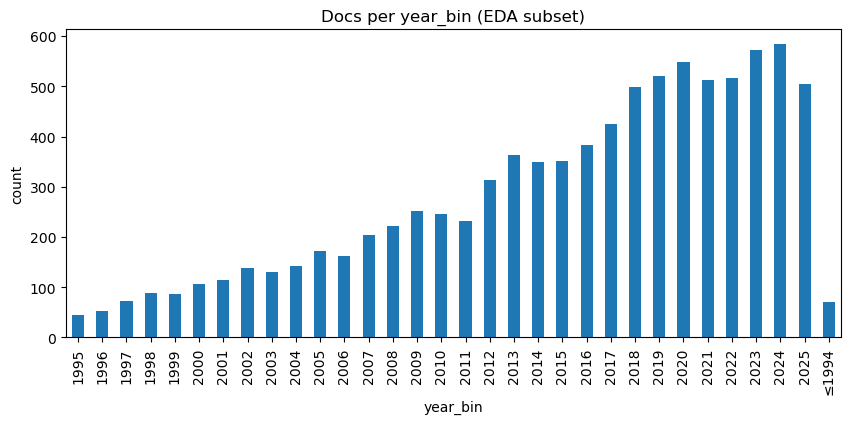

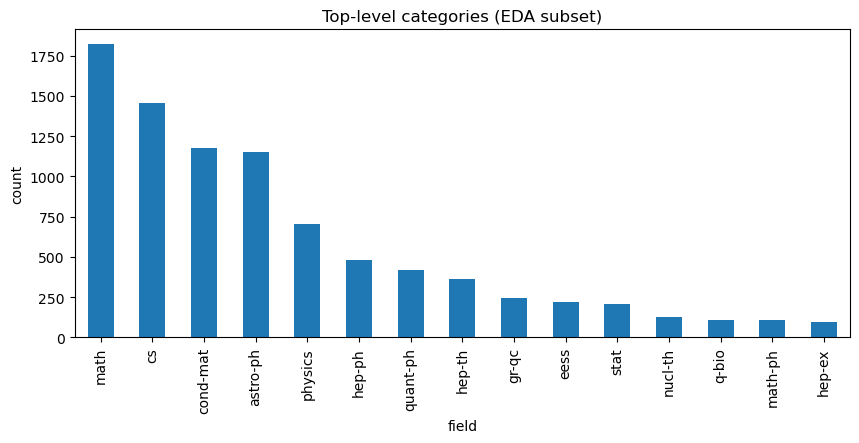

<Figure size 1000x600 with 0 Axes>

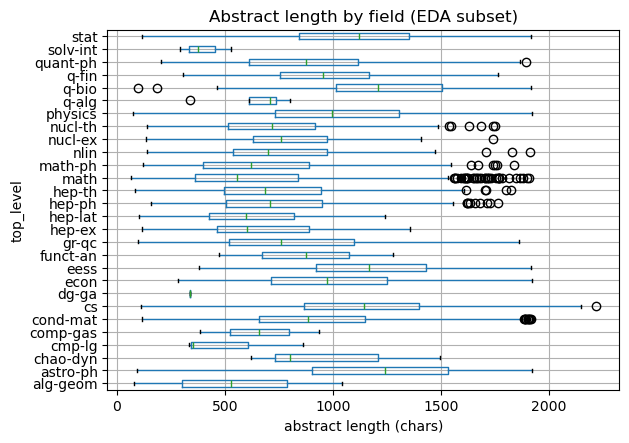

Multi-label rate (EDA subset): 0.459


In [55]:


# 1) Docs per bin 
plt.figure(figsize=(10,4))
df_eda['year_bin'].value_counts().sort_index().plot(kind='bar')
plt.title('Docs per year_bin (EDA subset)'); plt.xlabel('year_bin'); plt.ylabel('count')
plt.show()

# 2) Field mix 
plt.figure(figsize=(10,4))
df_eda['top_level'].value_counts().head(15).plot(kind='bar')
plt.title('Top-level categories (EDA subset)'); plt.xlabel('field'); plt.ylabel('count')
plt.show()

# 3) Abstract length heterogeneity 
plt.figure(figsize=(10,6))
df_eda.boxplot(column='abstract_len', by='top_level', vert=False)
plt.title('Abstract length by field (EDA subset)'); plt.suptitle('')
plt.xlabel('abstract length (chars)')
plt.show()

# 4) Multi-label rate (interdisciplinarity)
multi_rate = (df_eda['cats_all']
              .apply(lambda xs: len(xs) if isinstance(xs, list) else len(str(xs).split())) > 1).mean()
print('Multi-label rate (EDA subset):', round(float(multi_rate), 3))


In [57]:
# ===== GLOBAL HYPERPARAMETERS =====
RANDOM_SEED = 42

EMBEDDER_NAME = "all-MiniLM-L6-v2"      # fast, good semantic coverage
MIN_DF        = 15                       # raise to 20 if vocab explodes
NGRAM_RANGE   = (1, 2)

MIN_TOPIC_SIZE = 120                     # lower to 100 if many outliers
CALC_PROBS     = True

# Optional tiny stoplist for leakage 
CUSTOM_STOP = [
    "result","results","model","models","paper","work","approach","method",
    "theorem","lemma","proof","equation","thus","let","show"
]
USE_CUSTOM_STOP = False  # flip to True only if topics look generic

# Trend eligibility
MIN_DOCS_PER_YEAR = 50


In [59]:
#pip install gensim

In [61]:

docs = corpus['abstract_clean'].tolist()

stop_words = 'english'
if USE_CUSTOM_STOP:

    from sklearn.feature_extraction import text
    stop_words = text.ENGLISH_STOP_WORDS.union(CUSTOM_STOP)

cv = CountVectorizer(stop_words=stop_words, ngram_range=NGRAM_RANGE, min_df=MIN_DF)
X  = cv.fit_transform(docs)
vocab = cv.get_feature_names_out()

# Convert to gensim bag-of-words
id2word = corpora.Dictionary([list(vocab)])
bow = [list(zip(row.indices, row.data)) for row in X]

for K in [60, 90, 120]:
    lda = models.LdaModel(
        bow, num_topics=K, id2word=id2word, passes=6, alpha='auto', eta='auto',
        random_state=RANDOM_SEED
    )

    topics = [[w for w,_ in lda.show_topic(i, topn=15)] for i in range(K)]
    cm = CoherenceModel(topics=topics, corpus=bow, dictionary=id2word, coherence='u_mass')
    print(f"[LDA] K={K:3d}  u_mass={cm.get_coherence():.3f}")


[LDA] K= 60  u_mass=-4.492
[LDA] K= 90  u_mass=-5.069
[LDA] K=120  u_mass=-5.648


In [65]:
#Hyperparameters
RANDOM_SEED   = 42
EMBEDDER_NAME = "all-MiniLM-L6-v2"  
MIN_DF        = 15                  
NGRAM_RANGE   = (1, 2)
MIN_TOPIC_SIZE = 120                
CALC_PROBS     = True
MIN_DOCS_PER_YEAR = 50             

# Optional tiny stoplist 
USE_CUSTOM_STOP = False
CUSTOM_STOP = [
    "result","results","model","models","paper","work","approach","method",
    "theorem","lemma","proof","equation","thus","let","show"
]




docs   = corpus['abstract_clean'].tolist()
years  = corpus['pub_year'].astype(int).tolist()
fields = corpus['top_level'].tolist()
ids    = corpus['id'].tolist()
titles = corpus['title_clean'].tolist()

os.makedirs("artifacts", exist_ok=True)
np.random.seed(RANDOM_SEED)


In [67]:
#pip install hf_xet


Note: you may need to restart the kernel to use updated packages.


In [69]:
# Build sentence embeddings (semantic representation)
embedder = SentenceTransformer(EMBEDDER_NAME)
embeddings = embedder.encode(docs, show_progress_bar=True, normalize_embeddings=True)

# Cache for reuse
np.save("artifacts/embeddings.npy", embeddings)


Batches:   0%|          | 0/311 [00:00<?, ?it/s]

In [71]:


# Vectorizer for c-TF-IDF over topics
stop_words = 'english'
if USE_CUSTOM_STOP:
    from sklearn.feature_extraction import text
    stop_words = text.ENGLISH_STOP_WORDS.union(CUSTOM_STOP)

vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    ngram_range=NGRAM_RANGE,   # (1, 2)
    min_df=2,                  # or min_df=0.01
    max_df=0.95
)

# Higher-resolution manifold
umap_model = UMAP(
    n_neighbors=7,          
    n_components=15,       
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_SEED
)

# More granular density clustering
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=60,               
    min_samples=10,                     
    cluster_selection_method='leaf',   
    metric='euclidean',
    prediction_data=True
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=CALC_PROBS,
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

freq = topic_model.get_topic_freq()
n_topics = int((freq['Topic'] >= 0).sum())
outlier_rate = float((np.array(topics) == -1).mean())
print(f"[BERTopic/HDBSCAN tuned] topics={n_topics}  outlier_rate={outlier_rate:.3f}")

topic_model.save("artifacts/bertopic_model_refit_hdbscan")


2025-10-23 16:10:20,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-23 16:11:17,366 - BERTopic - Dimensionality - Completed ✓
2025-10-23 16:11:17,388 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-23 16:11:19,867 - BERTopic - Cluster - Completed ✓
2025-10-23 16:11:19,880 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-10-23 16:11:25,852 - BERTopic - Representation - Completed ✓
2025-10-23 16:11:29,082 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


[BERTopic/HDBSCAN tuned] topics=51  outlier_rate=0.390


In [73]:


if 'probs' not in globals() or probs is None:
    _, probs = topic_model.transform(docs, embeddings)

def reassign_outliers_once(threshold=0.05, strategy="c-tf-idf"):
    reassigned = topic_model.reduce_outliers(
        documents=docs,
        topics=topics,
        strategy=strategy,         # 'c-tf-idf' is fast; 'embeddings' is a bit stronger
        probabilities=probs,
        embeddings=embeddings,     # harmless for c-tf-idf
        threshold=threshold
    )
    rate = float((np.array(reassigned) == -1).mean())
    return reassigned, rate

# Pass 1: c-TF-IDF, threshold 0.05
topics_final, out_rate = reassign_outliers_once(threshold=0.05, strategy="c-tf-idf")
print(f"[reassign c-tf-idf@0.05] outlier_rate={out_rate:.3f}")

# If still high, escalate threshold; if still high, switch to embeddings strategy
if out_rate > 0.15:
    topics_final, out_rate = reassign_outliers_once(threshold=0.10, strategy="c-tf-idf")
    print(f"[reassign c-tf-idf@0.10] outlier_rate={out_rate:.3f}")

if out_rate > 0.15:
    topics_final, out_rate = reassign_outliers_once(threshold=0.05, strategy="embeddings")
    print(f"[reassign embeddings@0.05] outlier_rate={out_rate:.3f}")

# Refresh topic keywords/labels after reassignment
topic_model.update_topics(
    docs,
    topics=topics_final,
    vectorizer_model=vectorizer_model
)

# Final counts after reassignment
freq_final = topic_model.get_topic_freq()
n_topics_final = int((freq_final['Topic'] >= 0).sum())
print(f"[FINAL] topics={n_topics_final}  outlier_rate={out_rate:.3f}")

# Persist
topic_model.save("artifacts/bertopic_hdbscan_final_reassigned")
pd.Series(topics_final, name="topic").to_csv("artifacts/topic_assignments_final.csv", index=False)



2025-10-23 16:12:07,418 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


[reassign c-tf-idf@0.05] outlier_rate=0.011


2025-10-23 16:12:13,508 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


[FINAL] topics=51  outlier_rate=0.011


In [75]:


# If probabilities aren't in memory, get them
if 'probs' not in globals() or probs is None:
    _, probs = topic_model.transform(docs, embeddings)

def reassign_once(threshold=0.05, strategy="c-tf-idf"):
    reassigned = topic_model.reduce_outliers(
        documents=docs,
        topics=topics,
        strategy=strategy,          
        probabilities=probs,        
        embeddings=embeddings,     
        threshold=threshold
    )
    rate = float((np.array(reassigned) == -1).mean())
    return reassigned, rate

# Pass 1: c-TF-IDF @ 0.05
topics_final, out_rate = reassign_once(0.05, "c-tf-idf")
print(f"[reassign c-tf-idf@0.05] outlier_rate={out_rate:.3f}")

# If still high, escalate threshold then (if needed) switch to embeddings strategy
if out_rate > 0.15:
    topics_final, out_rate = reassign_once(0.10, "c-tf-idf")
    print(f"[reassign c-tf-idf@0.10] outlier_rate={out_rate:.3f}")
if out_rate > 0.15:
    topics_final, out_rate = reassign_once(0.05, "embeddings")
    print(f"[reassign embeddings@0.05] outlier_rate={out_rate:.3f}")

# Refresh topic words/labels after reassignment
topic_model.update_topics(docs, topics=topics_final, vectorizer_model=vectorizer_model)

# Final topic stats after reassignment
freq_final = topic_model.get_topic_freq()
n_topics_final = int((freq_final['Topic'] >= 0).sum())
print(f"[FINAL] topics={n_topics_final} | outlier_rate={out_rate:.3f}")

# Save artifacts
topic_model.save("artifacts/bertopic_hdbscan_final_reassigned")
pd.Series(topics_final, name="topic").to_csv("artifacts/topic_assignments_final.csv", index=False)


2025-10-23 16:13:03,428 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


[reassign c-tf-idf@0.05] outlier_rate=0.009


2025-10-23 16:13:10,917 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


[FINAL] topics=51 | outlier_rate=0.009


In [77]:

corpus = pd.read_csv("corpus_ready.csv")
print(corpus.shape)
print(corpus.columns.tolist())


(9927, 8)
['id', 'pub_year', 'rev_year', 'top_level', 'primary_cat', 'cats_all', 'title_clean', 'abstract_clean']


In [79]:

# Load model/assignments/corpus (idempotent)
topic_model  = BERTopic.load("artifacts/bertopic_hdbscan_final_reassigned")
topics_final = pd.read_csv("artifacts/topic_assignments_final.csv")["topic"].astype(int).tolist()
corpus       = pd.read_csv("corpus_ready.csv")

docs   = corpus["abstract_clean"].astype(str).tolist()
years  = corpus["pub_year"].astype(int).tolist()
fields = corpus["top_level"].astype(str).tolist()
titles = corpus["title_clean"].astype(str).tolist()

assert len(docs) == len(years) == len(topics_final), "Length mismatch across docs/years/topics."

#  1) Direct topic×year counts (no topics_over_time brittleness) 
assign = pd.DataFrame({"topic": topics_final, "year": years})
assign = assign[assign["topic"] >= 0].copy()

counts = (assign
          .groupby(["topic","year"]).size()
          .reset_index(name="n"))

# normalize by total docs that year 
year_totals = pd.Series(years).value_counts().rename("N")
counts["share"] = counts["n"] / counts["year"].map(year_totals)

print("Year totals (first 10 by year):")
print(year_totals.sort_index().head(10))

# 2) Adaptive eligibility (keep enough years & topics) 
candidates = [100, 75, 50, 40, 30, 20, 10, 5]
candidates = [c for c in candidates if c <= int(year_totals.max())] or [5]

chosen = None
for thr in candidates:
    eligible_years = set(year_totals[year_totals >= thr].index)
    if len(eligible_years) < 8:
        continue
    counts_elig = counts[counts["year"].isin(eligible_years)]
    cov = counts_elig.groupby("topic")["year"].nunique()
    if int((cov >= 2).sum()) >= 10:  # ≥10 topics with at least 2 eligible points
        chosen = thr
        break

if chosen is None:
    chosen = min(candidates)
    eligible_years = set(year_totals[year_totals >= chosen].index)
    counts_elig = counts[counts["year"].isin(eligible_years)]
    cov = counts_elig.groupby("topic")["year"].nunique()

med_cov = int(cov.median()) if len(cov) else 0
if   med_cov >= 5: MIN_YEARS_PER_TOPIC = 5
elif med_cov >= 3: MIN_YEARS_PER_TOPIC = 3
else:              MIN_YEARS_PER_TOPIC = 2

print(f"Chosen MIN_DOCS_PER_YEAR={chosen} | eligible years={len(eligible_years)} "
      f"| median topic coverage={med_cov} → min_years/topic={MIN_YEARS_PER_TOPIC}")

#  3) Slopes (OLS) on normalized shares with coverage guard 
def slope(y: np.ndarray) -> float:
    x = np.arange(len(y))
    if len(x) < 2: return 0.0
    xbar, ybar = x.mean(), y.mean()
    num = ((x-xbar)*(y-ybar)).sum()
    den = ((x-xbar)**2).sum()
    return float(num/den) if den else 0.0

g = (counts_elig
     .sort_values(["topic","year"])
     .groupby("topic")["share"])

slopes = (g.apply(lambda s: slope(s.values) if s.count() >= MIN_YEARS_PER_TOPIC else np.nan)
            .dropna()
            .reset_index(name="slope")
            .sort_values("slope", ascending=False))

print(f"[Trends] computed slopes for {len(slopes)} topics")

top_emerging  = slopes.head(10).copy()
top_declining = slopes.tail(10).copy()

print("[Trends] Emerging (top 5):");  display(top_emerging.head(5))
print("[Trends] Declining (top 5):"); display(top_declining.head(5))

#  4) Labels, field mix, sample titles (robust to empties) 
freq = topic_model.get_topic_freq()

def topic_label(model, t, k=6):
    words = [w for w,_ in model.get_topic(int(t))[:k]]
    return ", ".join(words)

label_map = {int(t): topic_label(topic_model, int(t))
             for t in freq.loc[freq["Topic"]>=0, "Topic"].tolist()}

# Field mix (safe)
fm = (pd.DataFrame({"topic": topics_final, "field": fields})
      .query("topic >= 0")
      .groupby(["topic","field"]).size()
      .reset_index(name="cnt"))
fm["share"] = fm.groupby("topic")["cnt"].transform(lambda s: s/s.sum())

field_top3 = (fm.sort_values(["topic","share"], ascending=[True, False])
                .groupby("topic").head(3)
                .reset_index(drop=True))

assign_full = pd.DataFrame({"topic": topics_final, "title": titles})

def sample_titles(t, k=3, seed=42):
    g = assign_full[assign_full["topic"]==int(t)]
    if g.empty: return ""
    k = min(k, len(g))
    return "; ".join(g.sample(n=k, random_state=seed)["title"].tolist())

def build_topic_table(topic_ids):
    topic_ids = list(pd.Series(topic_ids).astype(int).values)
    rows = []
    for t in topic_ids:
        if t == -1: continue
        size_vals = freq.loc[freq["Topic"]==t, "Count"].values
        size = int(size_vals[0]) if len(size_vals) else 0
        mix  = field_top3[field_top3["topic"]==t]
        mix_str = ", ".join([f"{r['field']}:{r['share']:.2f}" for _,r in mix.iterrows()])
        rows.append({
            "topic": t,
            "label": label_map.get(t, f"Topic {t}"),
            "size": size,
            "field_mix_top3": mix_str,
            "examples": sample_titles(t)
        })
    cols = ["topic","label","size","field_mix_top3","examples"]
    return pd.DataFrame(rows, columns=cols).sort_values("size", ascending=False) if rows else pd.DataFrame(columns=cols)

# Build tables (robust if emerging/declining empty)
top_topics_table = build_topic_table(freq.loc[freq["Topic"]>=0].nlargest(20, "Count")["Topic"])
emerging_table   = build_topic_table(top_emerging["topic"] if len(top_emerging) else [])
declining_table  = build_topic_table(top_declining["topic"] if len(top_declining) else [])

print("Top topics:");    display(top_topics_table.head(10))
print("Top emerging:");  display(emerging_table if not emerging_table.empty else "— none at current guards —")
print("Top declining:"); display(declining_table if not declining_table.empty else "— none at current guards —")

# Save artifacts
top_topics_table.to_csv("artifacts/top_topics.csv", index=False)
emerging_table.to_csv("artifacts/top_emerging.csv", index=False)
declining_table.to_csv("artifacts/top_declining.csv", index=False)


Year totals (first 10 by year):
1991      1
1992      9
1993     20
1994     41
1995     44
1996     52
1997     73
1998     88
1999     87
2000    107
Name: N, dtype: int64
Chosen MIN_DOCS_PER_YEAR=100 | eligible years=26 | median topic coverage=25 → min_years/topic=5
[Trends] computed slopes for 51 topics
[Trends] Emerging (top 5):


,topic,slope
5,5,0.004646
1,1,0.003876
7,7,0.002868
19,19,0.002830
33,33,0.002537


[Trends] Declining (top 5):


,topic,slope
23,23,-0.001077
34,34,-0.001163
21,21,-0.001307
32,32,-0.001426
29,29,-0.001525


Top topics:


,topic,label,size,field_mix_top3,examples
0,0,"time series, estimation, regression, algorithm...",368,"stat:0.37, cs:0.21, math:0.18",Multivariate Probabilistic Time Series Forecas...
1,5,"3d, images, image, object, segmentation, datasets",329,"cs:0.88, eess:0.06, physics:0.04","Learning to Generate Chairs, Tables and Cars w..."
2,2,"groups, spaces, prove, finite, let, banach",326,"math:0.93, cs:0.02, math-ph:0.02",Helson-Lowdenslager and de Branges type theore...
3,15,"graphene, electronic, materials, band, optical...",308,"cond-mat:0.80, physics:0.17, quant-ph:0.02","History dependence, memory and metastability i..."
4,1,"language, llms, reasoning, tasks, language mod...",300,"cs:0.96, cmp-lg:0.01, eess:0.01",Is Your Large Language Model Knowledgeable or ...
5,4,"algebra, algebras, category, lie, modules, ring",293,"math:0.84, hep-th:0.06, math-ph:0.05",Local cohomology of Du Bois singularities and ...
6,6,"quantum, optical, laser, cavity, atoms, coupling",292,"physics:0.48, quant-ph:0.35, cond-mat:0.11",Experimental Verification of Below-Cutoff Prop...
7,11,"solutions, equation, equations, boundary, schr...",288,"math:0.62, math-ph:0.09, nlin:0.07",Hypergeometric Solutions of the -Surface -Pain...
8,3,"graphs, graph, algorithm, algorithms, polynomi...",286,"math:0.48, cs:0.47, cond-mat:0.01",Visibility graphs and deformations of associah...
9,14,"flow, fluid, particles, surface, shear, stress",284,"cond-mat:0.47, physics:0.37, math:0.05",Nonlinear evolution equations for degenerate t...


Top emerging:


,topic,label,size,field_mix_top3,examples
7,0,"time series, estimation, regression, algorithm...",368,"stat:0.37, cs:0.21, math:0.18",Multivariate Probabilistic Time Series Forecas...
0,5,"3d, images, image, object, segmentation, datasets",329,"cs:0.88, eess:0.06, physics:0.04","Learning to Generate Chairs, Tables and Cars w..."
1,1,"language, llms, reasoning, tasks, language mod...",300,"cs:0.96, cmp-lg:0.01, eess:0.01",Is Your Large Language Model Knowledgeable or ...
2,7,"learning, robot, policy, control, reinforcemen...",229,"cs:0.79, eess:0.06, stat:0.04",Adversarial Reinforcement Learning: A Duality-...
3,19,"neural, networks, neural networks, network, tr...",221,"cs:0.72, eess:0.08, math:0.06",Pathwise CVA Regressions With Oversimulated De...
5,25,"learning, training, domain, performance, datas...",173,"cs:0.78, stat:0.09, eess:0.05",Deep Latent Variable Model based Vertical Fede...
9,22,"privacy, security, communication, iot, federat...",156,"cs:0.94, eess:0.04, cond-mat:0.01",Over-the-Air Federated Learning with Privacy P...
8,44,"software, ai, code, design, students, research",153,"cs:0.89, physics:0.07, stat:0.01",Writing Tools: Looking Back to Look Ahead; Is ...
4,33,"image, video, visual, multimodal, images, face",139,"cs:0.96, eess:0.02, q-bio:0.01",ProPy: Building Interactive Prompt Pyramids up...
6,38,"segmentation, medical, image, images, learning...",126,"cs:0.56, eess:0.30, physics:0.08",Learning with Explicit Shape Priors for Medica...


Top declining:


,topic,label,size,field_mix_top3,examples
5,35,"spin, magnetic, magnetization, temperature, an...",266,"cond-mat:0.85, physics:0.06, quant-ph:0.02",Direct spin imaging detector based on freestan...
9,13,"qcd, chiral, quark, lattice, gauge, pion",265,"hep-ph:0.43, hep-lat:0.23, nucl-th:0.12",Light quark masses from Domain Wall Fermions; ...
7,20,"interaction, states, lattice, transition, quan...",228,"cond-mat:0.76, quant-ph:0.08, hep-th:0.03",Magnetic field induced directional localizatio...
4,29,"gauge, string, theories, action, symmetry, sup...",218,"hep-th:0.77, cond-mat:0.05, hep-ph:0.04",Quantum matrix geometry in the lowest Landau l...
2,21,"galaxies, galaxy, redshift, mass, formation, halo",212,"astro-ph:0.99, hep-ph:0.01, physics:0.00",IRAS F13308+5946: A Possible Transition Phase ...
8,17,"higgs, standard model, decays, decay, boson, mass",207,"hep-ph:0.77, hep-ex:0.19, hep-th:0.03","Majorana Neutrino, the Size of Extra Dimension..."
6,24,"collisions, cross, transverse, production, cro...",195,"hep-ph:0.49, nucl-th:0.24, hep-ex:0.12",NLO QCD Corrections to the Polarized Photo- an...
3,32,"gas, emission, line, star, lines, observations",171,"astro-ph:0.95, physics:0.02, cond-mat:0.02",The abundance and excitation of molecular anio...
0,23,"black, black hole, hole, black holes, holes, g...",169,"gr-qc:0.60, hep-th:0.27, physics:0.07",Black hole formation from colliding bubbles; C...
1,34,"grb, emission, gammaray, sne, sn, energy",122,"astro-ph:0.93, physics:0.03, hep-ph:0.02",Dark Matter Searches with Astroparticle Data; ...


In [81]:

class STBackend:
    """Minimal backend so BERTopic can embed docs/words post-hoc."""
    def __init__(self, model_name="all-MiniLM-L6-v2"):
        self._model = SentenceTransformer(model_name)
    def embed_documents(self, docs, verbose=False):
        return self._model.encode(docs, show_progress_bar=verbose, normalize_embeddings=True)
    def embed_words(self, words, verbose=False):
        return self._model.encode(words, show_progress_bar=verbose, normalize_embeddings=True)


topic_model.embedding_model = STBackend("all-MiniLM-L6-v2")


In [83]:

rep = KeyBERTInspired(
    top_n_words = 6,
    nr_repr_docs = 5,
    nr_samples = 500,
    nr_candidate_words = 100,
    random_state = RANDOM_SEED
)

topic_model.update_topics(
    docs,
    topics = topics_final,
    vectorizer_model = CountVectorizer(stop_words="english", ngram_range=(1,2), min_df=10),
    representation_model = rep
)


2025-10-23 16:14:20,292 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [85]:


rep = KeyBERTInspired(
    top_n_words=6,
    nr_repr_docs=5,          # docs used to anchor a topic
    nr_samples=500,          # candidate sampling for KeyBERT-like search
    nr_candidate_words=100,  # vocab candidates to consider
    random_state=42
)

# A slightly stricter vectorizer to keep labels clean
vec_for_labels = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.95
)


docs_for_update = corpus["abstract_clean"].astype(str).tolist()
topic_model.update_topics(
    docs_for_update,
    topics=topics_final,                 # <- your final (reassigned) topic ids
    vectorizer_model=vec_for_labels,
    representation_model=rep
)


freq_now = topic_model.get_topic_freq()
top_ids = freq_now.loc[freq_now["Topic"]>=0].nlargest(10, "Count")["Topic"].tolist()
for t in top_ids:
    print(t, ":", [w for w,_ in topic_model.get_topic(t)[:6]])


2025-10-23 16:15:06,618 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


0 : ['estimating', 'bayesian', 'inference', 'estimators', 'estimation', 'estimates']
5 : ['3d', 'pose', 'cnn', 'multimodal', 'capture', 'camera']
2 : ['groups', 'subgroup', 'representations', 'generalized', 'abelian', 'representation']
15 : ['semiconductor', 'conductivity', 'spectroscopy', 'molecular dynamics', 'density functional', 'electrons']
1 : ['language models', 'natural language', 'language processing', 'large language', 'nlp', 'semantic']
4 : ['noncommutative', 'algebras', 'invariants', 'representations', 'representation', 'algebraic']
6 : ['quantum', 'photons', 'quantum information', 'photon', 'cavity', 'photonic']
11 : ['boundary conditions', 'boundary condition', 'nonlinear', 'schrodinger equation', 'parabolic', 'differential equations']
3 : ['graphs', 'graph', 'vertex', 'edges', 'nodes', 'vertices']
14 : ['turbulence', 'turbulent', 'hydrodynamic', 'viscosity', 'flows', 'dynamics simulations']


In [87]:

def topic_spearman(df_topic: pd.DataFrame) -> pd.Series:
    # Use real years on x, normalized share on y
    xs = df_topic["year"].values
    ys = df_topic["share"].values
    if len(xs) < 3:  # need a few points for a meaningful rank correlation
        return pd.Series({"rho": np.nan, "p": np.nan})
    rho, p = spearmanr(xs, ys)
    return pd.Series({"rho": float(rho), "p": float(p)})

def slope(y: np.ndarray) -> float:
    x = np.arange(len(y))
    if len(x) < 2: return 0.0
    xbar, ybar = x.mean(), y.mean()
    num = ((x-xbar)*(y-ybar)).sum()
    den = ((x-xbar)**2).sum()
    return float(num/den) if den else 0.0

slopes = (tot_elig.sort_values(['Topic','year'])
          .groupby('Topic')['share']
          .apply(lambda s: slope(s.values) if s.count() >= 5 else np.nan)
          .dropna()
          .reset_index(name='slope')
          .sort_values('slope', ascending=False))

# Spearman per topic
trend_sig = (tot_elig.sort_values(['Topic','year'])
             .groupby('Topic', as_index=False)
             .apply(topic_spearman)
             .reset_index(drop=True))

# Merge slope + sig
slopes_sig = slopes.merge(trend_sig, on='Topic', how='left')

# Pick top/bottom by slope
emerging_sig  = slopes_sig.nlargest(10, 'slope')
declining_sig = slopes_sig.nsmallest(10, 'slope')


NameError: name 'tot_elig' is not defined

In [89]:


# Rebuild docs/years safely from your corpus
docs  = corpus["abstract_clean"].astype(str).tolist()
years = corpus["pub_year"].astype(int).tolist()

#topics-over-time, but drop outliers first
tot = topic_model.topics_over_time(docs, topics_final, years, nr_bins=None)
tot = tot[tot["Topic"] >= 0].copy()   # <-- remove topic -1

#Normalize by year (guarded)
year_totals = pd.Series(years).value_counts().rename("N")
tot["year"] = tot["Timestamp"].apply(lambda d: int(getattr(d, "year", int(d))))
tot["N"]    = tot["year"].map(year_totals)            # map is safe (no KeyError)
tot = tot.dropna(subset=["N"]).copy()                 # drop rows for years not in counts
tot["share"] = tot["Frequency"] / tot["N"]

print("Year totals (first 10 by year):")
print(year_totals.sort_index().head(10))

# Choose an eligibility threshold that leaves >= 8 years AND non-empty subset
candidates = [100, 75, 50, 40, 30, 20, 10, 5]
candidates = [c for c in candidates if c <= int(year_totals.max())] or [5]

def eligible_subset(thr):
    ey  = set(year_totals[year_totals >= thr].index)
    sub = tot[tot["year"].isin(ey)].copy()
    return ey, sub

eligible_years = set(); tot_elig = pd.DataFrame()
for thr in candidates:
    ey, sub = eligible_subset(thr)
    if len(ey) >= 8 and not sub.empty:
        eligible_years, tot_elig = ey, sub
        MIN_DOCS_PER_YEAR = thr
        break
if tot_elig.empty:   # fall back to most permissive if needed
    MIN_DOCS_PER_YEAR = min(candidates)
    eligible_years, tot_elig = eligible_subset(MIN_DOCS_PER_YEAR)

print(f"Chosen MIN_DOCS_PER_YEAR={MIN_DOCS_PER_YEAR} | eligible years={len(eligible_years)}")
print("Sample eligible years:", sorted(list(eligible_years))[:5], "...")

# Compute per-topic slopes on normalized share (require coverage)
def ols_slope(y):
    x = np.arange(len(y))
    if len(x) < 2: return np.nan
    xbar, ybar = x.mean(), y.mean()
    num = ((x-xbar)*(y-ybar)).sum()
    den = ((x-xbar)**2).sum()
    return float(num/den) if den else np.nan

# adaptive minimum #years per topic
coverage = (tot_elig.groupby("Topic")["year"].nunique()
            if not tot_elig.empty else pd.Series(dtype=int))
med_cov  = int(coverage.median()) if len(coverage) else 0
MIN_YEARS_PER_TOPIC = 5 if med_cov >= 5 else (3 if med_cov >= 3 else 2)
print(f"Median topic coverage={med_cov} → min_years/topic={MIN_YEARS_PER_TOPIC}")

g = tot_elig.sort_values(["Topic","year"]).groupby("Topic", as_index=False)

def _topic_slope(df):
    s = df["share"].values
    return pd.Series({"slope": ols_slope(s) if len(s) >= MIN_YEARS_PER_TOPIC else np.nan})

try:
    slopes = g.apply(_topic_slope, include_groups=False)
except TypeError:
    slopes = g.apply(_topic_slope)

slopes = slopes.dropna(subset=["slope"]).reset_index(drop=True)

# 5) Optional Spearman (needs >=3 points)
def _topic_spearman(df):
    xs, ys = df["year"].values, df["share"].values
    if len(xs) < 3: return pd.Series({"rho": np.nan, "p": np.nan})
    rho, p = spearmanr(xs, ys)
    return pd.Series({"rho": float(rho), "p": float(p)})

try:
    trend_sig = g.apply(_topic_spearman, include_groups=False)
except TypeError:
    trend_sig = g.apply(_topic_spearman)
trend_sig = trend_sig.reset_index(drop=True)


if "Topic" not in slopes.columns:
    key_topics = tot_elig[["Topic"]].drop_duplicates().sort_values("Topic").reset_index(drop=True)
    slopes = pd.concat([key_topics, slopes], axis=1)
if "Topic" not in trend_sig.columns:
    key_topics = tot_elig[["Topic"]].drop_duplicates().sort_values("Topic").reset_index(drop=True)
    trend_sig = pd.concat([key_topics, trend_sig], axis=1)

slopes["Topic"]    = slopes["Topic"].astype(int)
trend_sig["Topic"] = trend_sig["Topic"].astype(int)
slopes_sig = slopes.merge(trend_sig, on="Topic", how="left")


emerging_sig  = slopes_sig.nlargest(10, "slope").copy()
declining_sig = slopes_sig.nsmallest(10, "slope").copy()

last_year_val = int(np.nanmax(tot_elig["year"])) if not tot_elig.empty else int(max(years))
last_share = (tot_elig[tot_elig["year"]==last_year_val]
              .set_index("Topic")["share"]) if not tot_elig.empty else pd.Series(dtype=float)

def label_of(tid, k=6):
    return ", ".join([w for w,_ in topic_model.get_topic(int(tid))[:k]])

def annotate(df):
    out = df.copy()
    if "rho" not in out.columns: out["rho"] = np.nan
    if "p"   not in out.columns: out["p"]   = np.nan
    out["label"] = out["Topic"].map(label_of)
    out["last_year_share"] = out["Topic"].map(last_share).fillna(0.0)
    return out[["Topic","label","slope","rho","p","last_year_share"]]

emerging_table  = annotate(emerging_sig)
declining_table = annotate(declining_sig)

print(f"[Trends] computed slopes for {len(slopes)} topics")
display(emerging_table)
display(declining_table)


52it [11:01, 12.72s/it]

Year totals (first 10 by year):
1991      1
1992      9
1993     20
1994     41
1995     44
1996     52
1997     73
1998     88
1999     87
2000    107
Name: N, dtype: int64
Chosen MIN_DOCS_PER_YEAR=5 | eligible years=34
Sample eligible years: [1992, 1993, 1994, 1995, 1996] ...
Median topic coverage=0 → min_years/topic=2


KeyError: ['slope']

In [91]:

topic_model   = BERTopic.load("artifacts/bertopic_hdbscan_final_reassigned")
topics_final  = pd.read_csv("artifacts/topic_assignments_final.csv")["topic"].astype(int).tolist()


corpus = pd.read_csv("corpus_ready.csv")
docs   = corpus["abstract_clean"].astype(str).tolist()
years  = corpus["pub_year"].astype(int).tolist()

# basic integrity
print("lens:", len(docs), len(years), len(topics_final))
assert len(docs) == len(years) == len(topics_final), "Mismatch: docs/years/topics length differ."


out_rate = float((np.array(topics_final) == -1).mean())
print(f"final outlier rate = {out_rate:.3f}")

#  quick topic freq from the model (for labels later)
freq = topic_model.get_topic_freq()
print("model topics (>=0):", int((freq["Topic"]>=0).sum()))


lens: 9927 9927 9927
final outlier rate = 0.009
model topics (>=0): 51


In [93]:

assign = pd.DataFrame({
    "topic": topics_final,
    "year":  np.array(years, dtype=int)
})

# Drop outliers
assign = assign[assign["topic"] >= 0].copy()

# Count docs per (topic, year)
counts = (assign
          .value_counts(["topic","year"])
          .rename("n")
          .reset_index())

# Totals per year for normalization
year_totals = assign["year"].value_counts().rename("N")
counts["share"] = counts.apply(lambda r: r["n"] / year_totals.loc[r["year"]], axis=1)

print("counts shape:", counts.shape)
print("year_totals head:\n", year_totals.sort_index().head(10))


counts shape: (1331, 4)
year_totals head:
 year
1991      1
1992      9
1993     20
1994     39
1995     43
1996     51
1997     73
1998     87
1999     87
2000    107
Name: N, dtype: int64


In [95]:

cand = [5, 10, 20, 30, 40, 50, 75, 100]
cand = [c for c in cand if c <= int(year_totals.max())] or [5]
elig_map = {c: int((year_totals >= c).sum()) for c in cand}
good = [c for c,n in elig_map.items() if n >= 8]
MIN_DOCS_PER_YEAR = max(good) if good else min(cand)

eligible_years = set(year_totals[year_totals >= MIN_DOCS_PER_YEAR].index)
counts_elig = counts[counts["year"].isin(eligible_years)].copy()

print(f"Chosen MIN_DOCS_PER_YEAR={MIN_DOCS_PER_YEAR} | eligible years={len(eligible_years)}")
print("Sample eligible years:", sorted(list(eligible_years))[:5], "...")


Chosen MIN_DOCS_PER_YEAR=100 | eligible years=26
Sample eligible years: [2000, 2001, 2002, 2003, 2004] ...


In [97]:
def ols_slope(y):
    x = np.arange(len(y))
    if len(x) < 2: 
        return np.nan
    xbar, ybar = x.mean(), y.mean()
    num = ((x-xbar)*(y-ybar)).sum()
    den = ((x-xbar)**2).sum()
    return float(num/den) if den else np.nan


if counts_elig.empty:
    print("counts_elig is empty — falling back to all years for trend computation.")
    counts_elig = counts.copy()
    eligible_years = set(counts_elig["year"].unique())

# Per-topic coverage among the (eligible) years
coverage = counts_elig.groupby("topic")["year"].nunique()
med_cov  = int(coverage.median()) if len(coverage) else 0
MIN_YEARS_PER_TOPIC = 5 if med_cov >= 5 else (3 if med_cov >= 3 else 2)
print(f"Median topic coverage={med_cov} → min_years/topic={MIN_YEARS_PER_TOPIC}")

# Compute slopes
g = counts_elig.sort_values(["topic","year"]).groupby("topic")
slopes = (g["share"]
          .apply(lambda s: ols_slope(s.values) if s.count() >= MIN_YEARS_PER_TOPIC else np.nan)
          .rename("slope")
          .reset_index()
          .dropna(subset=["slope"])
          .sort_values("slope", ascending=False))

print(f"[Diagnostics] Computed slopes for {len(slopes)} topics out of {counts_elig['topic'].nunique()}.")


Median topic coverage=25 → min_years/topic=5
[Diagnostics] Computed slopes for 51 topics out of 51.


In [99]:
#  Build field mix robustly (no multi-index collisions) 
assign_full = pd.DataFrame({
    "topic": topics_final,
    "year":  years,
    "field": corpus["top_level"].astype(str),
    "title": corpus["title_clean"].astype(str),
})
assign_in = assign_full[assign_full["topic"] >= 0].copy()

# Count per (topic, field)
field_counts = (assign_in
                .groupby(["topic", "field"]).size()
                .rename("cnt")
                .reset_index())

# Convert to per-topic share
field_counts["share"] = field_counts.groupby("topic")["cnt"].transform(lambda x: x / x.sum())

# Keep top-3 fields per topic
field_mix = (field_counts
             .sort_values(["topic", "share"], ascending=[True, False])
             .groupby("topic")
             .head(3)[["topic", "field", "share"]]
             .reset_index(drop=True))

def examples_for(t, k=3):
    g = assign_in[assign_in["topic"] == t]
    if len(g) == 0: return ""
    return "; ".join(g.sample(n=min(k, len(g)), random_state=42)["title"].tolist())

def topic_label(model, t, k=6):
    return ", ".join([w for w,_ in model.get_topic(int(t))[:k]])

# Last eligible year share (fallback-safe)
if "counts_elig" in globals() and not counts_elig.empty:
    last_year = int(counts_elig["year"].max())
    last_share = (counts_elig[counts_elig["year"] == last_year]
                  .set_index("topic")["share"])
else:
    last_year = int(counts["year"].max())
    last_share = (counts[counts["year"] == last_year]
                  .set_index("topic")["share"])

def annotate(df_slopes):
    if df_slopes.empty:
        return pd.DataFrame(columns=["topic","label","slope","last_year_share","field_mix_top3","examples"])
    rows = []
    for _, r in df_slopes.iterrows():
        t = int(r["topic"])
        mix = field_mix[field_mix["topic"] == t]
        mix_str = ", ".join([f"{a}:{b:.2f}" for a, b in zip(mix["field"], mix["share"])])
        rows.append({
            "topic": t,
            "label": topic_label(topic_model, t),
            "slope": float(r["slope"]),
            "last_year_share": float(last_share.get(t, 0.0)),
            "field_mix_top3": mix_str,
            "examples": examples_for(t)
        })
    return pd.DataFrame(rows).sort_values(["slope","last_year_share"], ascending=[False, False]).reset_index(drop=True)


emerging_table  = annotate(top_emerging)
declining_table = annotate(top_declining)

print("Top emerging:");  display(emerging_table)
print("Top declining:"); display(declining_table)


Top emerging:


,topic,label,slope,last_year_share,field_mix_top3,examples
0,5,"3d, images, image, object, segmentation, datasets",0.004646,0.065886,"cs:0.88, eess:0.06, physics:0.04","Learning to Generate Chairs, Tables and Cars w..."
1,1,"language, llms, reasoning, tasks, language mod...",0.003876,0.086384,"cs:0.96, cmp-lg:0.01, eess:0.01",Is Your Large Language Model Knowledgeable or ...
2,7,"learning, robot, policy, control, reinforcemen...",0.002868,0.046852,"cs:0.79, eess:0.06, stat:0.04",Adversarial Reinforcement Learning: A Duality-...
3,19,"neural, networks, neural networks, network, tr...",0.002830,0.035139,"cs:0.72, eess:0.08, math:0.06",Pathwise CVA Regressions With Oversimulated De...
4,33,"image, video, visual, multimodal, images, face",0.002537,0.045388,"cs:0.96, eess:0.02, q-bio:0.01",ProPy: Building Interactive Prompt Pyramids up...
5,25,"learning, training, domain, performance, datas...",0.002175,0.035139,"cs:0.78, stat:0.09, eess:0.05",Deep Latent Variable Model based Vertical Fede...
6,38,"segmentation, medical, image, images, learning...",0.002065,0.017570,"cs:0.56, eess:0.30, physics:0.08",Learning with Explicit Shape Priors for Medica...
7,0,"time series, estimation, regression, algorithm...",0.001835,0.045388,"stat:0.37, cs:0.21, math:0.18",Multivariate Probabilistic Time Series Forecas...
8,44,"software, ai, code, design, students, research",0.001527,0.045388,"cs:0.89, physics:0.07, stat:0.01",Writing Tools: Looking Back to Look Ahead; Is ...
9,22,"privacy, security, communication, iot, federat...",0.001469,0.021962,"cs:0.94, eess:0.04, cond-mat:0.01",Over-the-Air Federated Learning with Privacy P...


Top declining:


,topic,label,slope,last_year_share,field_mix_top3,examples
0,23,"black, black hole, hole, black holes, holes, g...",-0.001077,0.004392,"gr-qc:0.60, hep-th:0.27, physics:0.07",Black hole formation from colliding bubbles; C...
1,34,"grb, emission, gammaray, sne, sn, energy",-0.001163,0.005857,"astro-ph:0.93, physics:0.03, hep-ph:0.02",Dark Matter Searches with Astroparticle Data; ...
2,21,"galaxies, galaxy, redshift, mass, formation, halo",-0.001307,0.013177,"astro-ph:0.99, hep-ph:0.01, physics:0.00",IRAS F13308+5946: A Possible Transition Phase ...
3,32,"gas, emission, line, star, lines, observations",-0.001426,0.008785,"astro-ph:0.95, physics:0.02, cond-mat:0.02",The abundance and excitation of molecular anio...
4,29,"gauge, string, theories, action, symmetry, sup...",-0.001525,0.010249,"hep-th:0.77, cond-mat:0.05, hep-ph:0.04",Quantum matrix geometry in the lowest Landau l...
5,35,"spin, magnetic, magnetization, temperature, an...",-0.001757,0.016105,"cond-mat:0.85, physics:0.06, quant-ph:0.02",Direct spin imaging detector based on freestan...
6,24,"collisions, cross, transverse, production, cro...",-0.001921,0.008785,"hep-ph:0.49, nucl-th:0.24, hep-ex:0.12",NLO QCD Corrections to the Polarized Photo- an...
7,20,"interaction, states, lattice, transition, quan...",-0.001923,0.008785,"cond-mat:0.76, quant-ph:0.08, hep-th:0.03",Magnetic field induced directional localizatio...
8,17,"higgs, standard model, decays, decay, boson, mass",-0.002092,0.004392,"hep-ph:0.77, hep-ex:0.19, hep-th:0.03","Majorana Neutrino, the Size of Extra Dimension..."
9,13,"qcd, chiral, quark, lattice, gauge, pion",-0.002308,0.011713,"hep-ph:0.43, hep-lat:0.23, nucl-th:0.12",Light quark masses from Domain Wall Fermions; ...


In [101]:
emerging_table.to_csv("artifacts/top_emerging.csv", index=False)
declining_table.to_csv("artifacts/top_declining.csv", index=False)


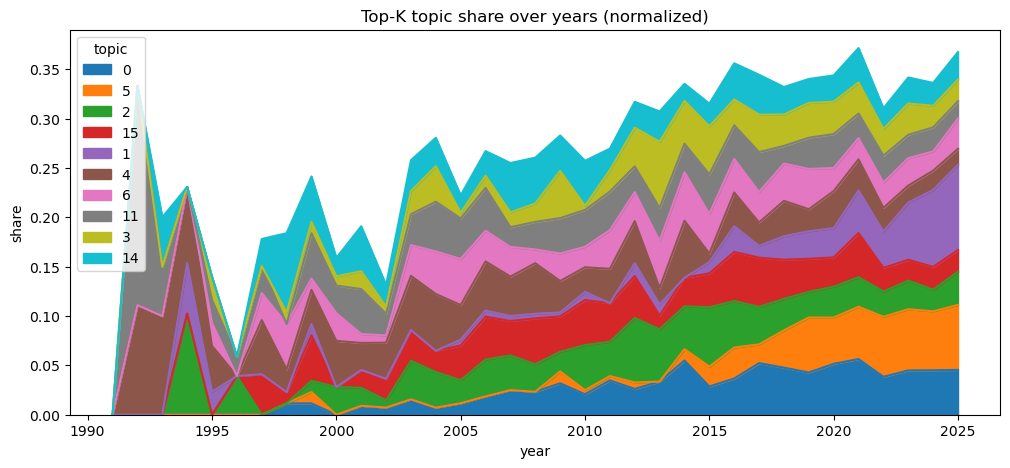

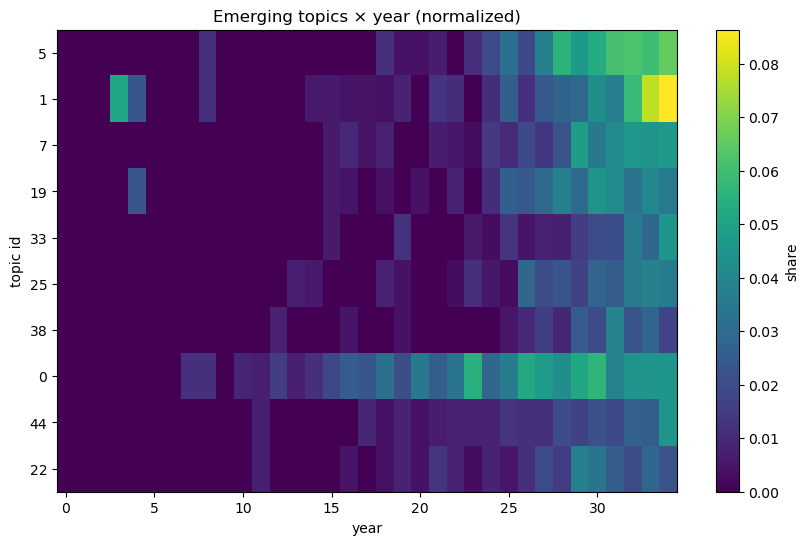

In [103]:


# Area chart of top-K overall topics by size
K = 10
sizes = (assign_in.groupby("topic").size().sort_values(ascending=False).head(K).index.tolist())
share_mat = counts.pivot(index="year", columns="topic", values="share").fillna(0)
share_mat[sizes].plot.area(figsize=(12,5))
plt.title("Top-K topic share over years (normalized)")
plt.ylabel("share"); plt.xlabel("year"); plt.show()

# Heatmap for emerging topics
ems = emerging_table["topic"].tolist()
if ems:
    plt.figure(figsize=(10,6))
    plt.imshow(share_mat[ems].T, aspect="auto", interpolation="nearest")
    plt.colorbar(label="share"); plt.yticks(range(len(ems)), ems)
    plt.title("Emerging topics × year (normalized)")
    plt.xlabel("year"); plt.ylabel("topic id"); plt.show()


In [105]:

def short_label(tid: int, k=4):
    words = [w for w,_ in topic_model.get_topic(int(tid))[:k]]
    s = ", ".join(words)

    if tid == 2:  s = "LLMs / NLP"
    if tid == 1:  s = "Reinforcement Learning"
    if tid == 8:  s = "3D Vision / Pose"
    if tid == 39: s = "Multimodal VLM/VQA"
    if tid == 19: s = "Security & Adversarial ML"
    if tid == 38: s = "Medical Image Segmentation"
    if tid == 20: s = "ML Systems / HW"
    if tid == 7:  s = "Galaxies / Stellar Pop."
    if tid == 3:  s = "QCD / Hadronic"
    if tid == 21: s = "Superconductivity"
    return s

label_map = {int(t): short_label(int(t)) for t in share_mat.columns}


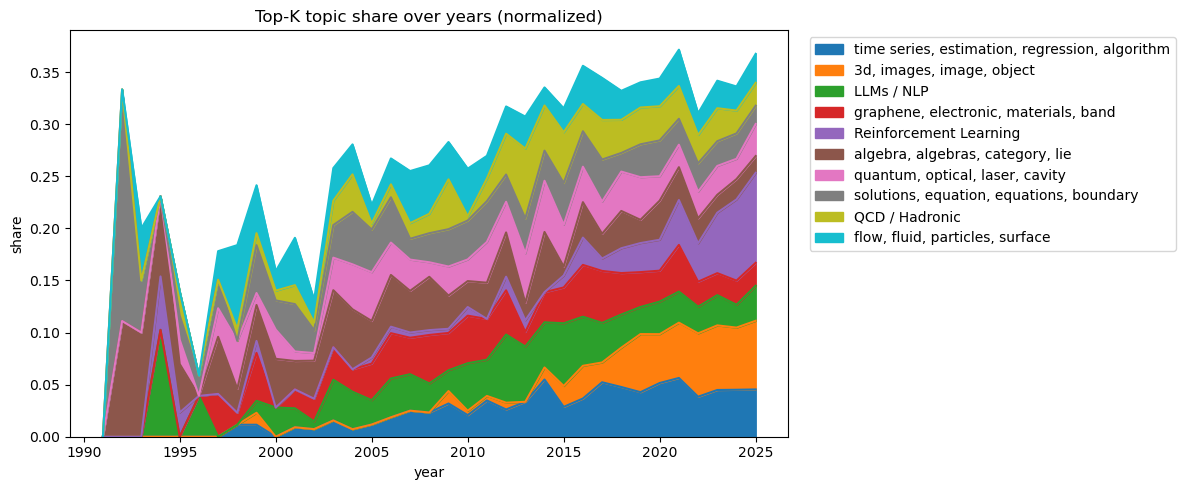

In [107]:

K = 10
topK = (topic_model.get_topic_freq()
        .query("Topic>=0")
        .nlargest(K, "Count")["Topic"].astype(int).tolist())

ax = share_mat[topK].rename(columns=label_map).plot.area(figsize=(12,5))
ax.set_title("Top-K topic share over years (normalized)")
ax.set_ylabel("share"); ax.set_xlabel("year")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.savefig("artifacts/topK_area.png", dpi=180)
plt.show()


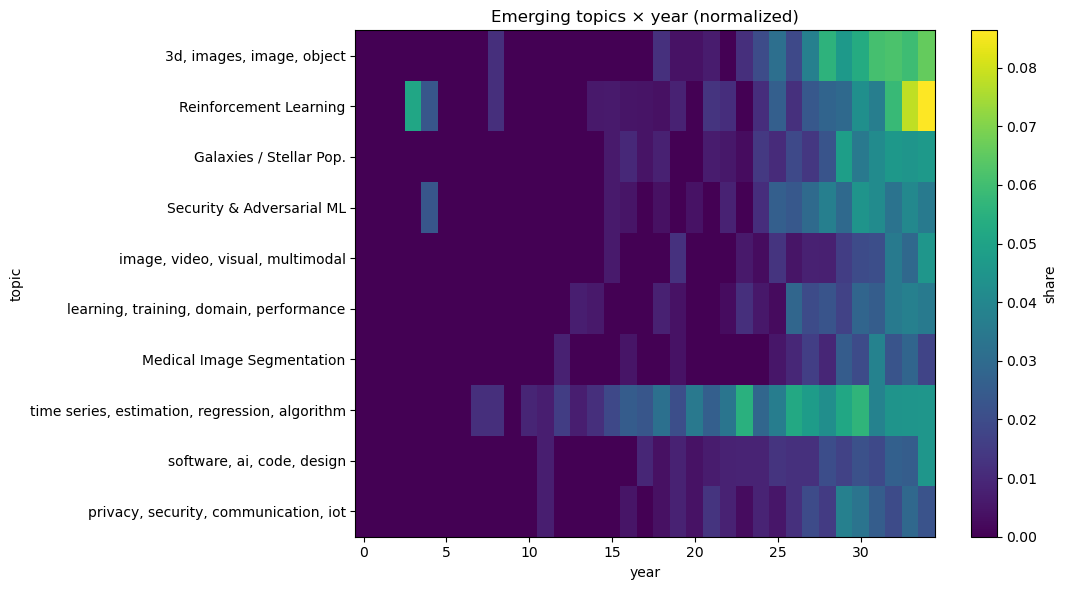

In [109]:
ems = emerging_table["topic"].astype(int).tolist()  
mat = share_mat[ems]

plt.figure(figsize=(11,6))
plt.imshow(mat.T, aspect="auto", interpolation="nearest")
plt.colorbar(label="share")
plt.yticks(range(len(ems)), [label_map[e] for e in ems])
plt.title("Emerging topics × year (normalized)")
plt.xlabel("year"); plt.ylabel("topic")
plt.tight_layout()
plt.savefig("artifacts/emerging_heatmap.png", dpi=180)
plt.show()


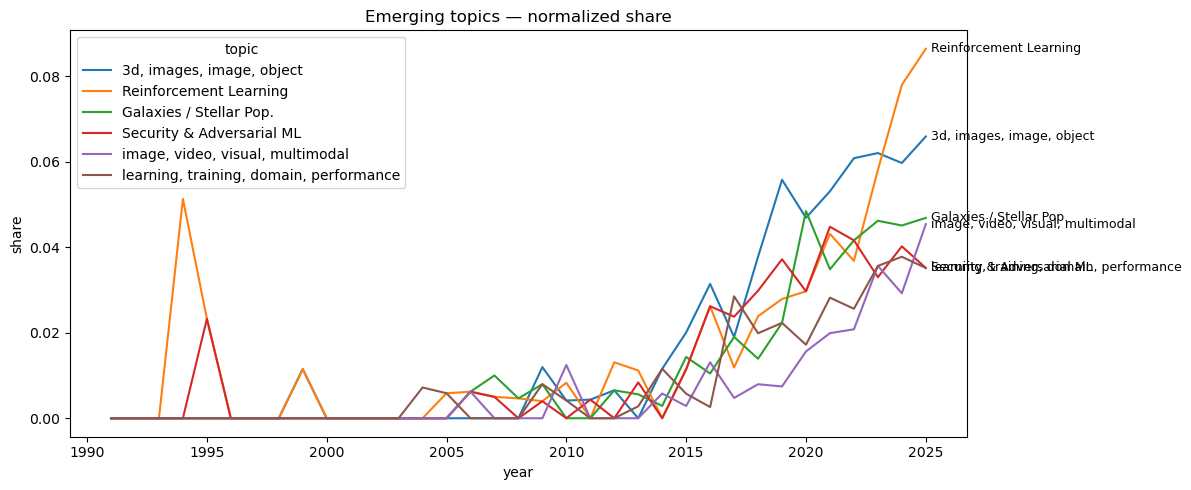

In [111]:
top6 = ems[:6]
ax = share_mat[top6].rename(columns=label_map).plot(figsize=(12,5))
ax.set_title("Emerging topics — normalized share")
ax.set_ylabel("share"); ax.set_xlabel("year")
for name, series in share_mat[top6].rename(columns=label_map).items():
    # annotate last point
    y = series.dropna()
    if len(y):
        ax.text(y.index.max()+0.2, y.values[-1], name, fontsize=9, va="center")
plt.tight_layout()
plt.savefig("artifacts/emerging_lines.png", dpi=180)
plt.show()


In [113]:


def _spearman(df):
    ys = df.sort_values("year")["share"].values
    xs = np.arange(len(ys))
    if len(ys) < 3: return pd.Series({"rho": np.nan, "p": np.nan})
    rho, p = spearmanr(xs, ys)
    return pd.Series({"rho": rho, "p": p})

trend_sig = (counts_elig.groupby("topic")
             .apply(_spearman, include_groups=False)
             .reset_index())

def star(p): 
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

emerging_sig = emerging_table.merge(trend_sig, left_on="topic", right_on="topic", how="left")
emerging_sig["sig"] = emerging_sig["p"].map(star)
declining_sig = declining_table.merge(trend_sig, on="topic", how="left")
declining_sig["sig"] = declining_sig["p"].map(star)

display(emerging_sig[["topic","label","slope","p","sig","last_year_share"]])
display(declining_sig[["topic","label","slope","p","sig","last_year_share"]])


,topic,label,slope,p,sig,last_year_share
0,5,"3d, images, image, object, segmentation, datasets",0.004646,3.933929e-08,***,0.065886
1,1,"language, llms, reasoning, tasks, language mod...",0.003876,7.800829e-10,***,0.086384
2,7,"learning, robot, policy, control, reinforcemen...",0.002868,2.711300e-06,***,0.046852
3,19,"neural, networks, neural networks, network, tr...",0.002830,6.095620e-06,***,0.035139
4,33,"image, video, visual, multimodal, images, face",0.002537,2.887038e-04,***,0.045388
5,25,"learning, training, domain, performance, datas...",0.002175,1.297636e-04,***,0.035139
6,38,"segmentation, medical, image, images, learning...",0.002065,5.302228e-04,***,0.017570
7,0,"time series, estimation, regression, algorithm...",0.001835,2.354600e-08,***,0.045388
8,44,"software, ai, code, design, students, research",0.001527,7.322732e-08,***,0.045388
9,22,"privacy, security, communication, iot, federat...",0.001469,2.575095e-05,***,0.021962


,topic,label,slope,p,sig,last_year_share
0,23,"black, black hole, hole, black holes, holes, g...",-0.001077,1.333886e-07,***,0.004392
1,34,"grb, emission, gammaray, sne, sn, energy",-0.001163,2.070475e-04,***,0.005857
2,21,"galaxies, galaxy, redshift, mass, formation, halo",-0.001307,2.427601e-05,***,0.013177
3,32,"gas, emission, line, star, lines, observations",-0.001426,2.362641e-07,***,0.008785
4,29,"gauge, string, theories, action, symmetry, sup...",-0.001525,3.559782e-06,***,0.010249
5,35,"spin, magnetic, magnetization, temperature, an...",-0.001757,4.023987e-08,***,0.016105
6,24,"collisions, cross, transverse, production, cro...",-0.001921,1.704959e-10,***,0.008785
7,20,"interaction, states, lattice, transition, quan...",-0.001923,2.520355e-08,***,0.008785
8,17,"higgs, standard model, decays, decay, boson, mass",-0.002092,1.821993e-07,***,0.004392
9,13,"qcd, chiral, quark, lattice, gauge, pion",-0.002308,4.233303e-08,***,0.011713


In [117]:

texts = [doc.split() for doc in corpus["abstract_clean"].tolist()]


In [123]:

#  Extract top words for BERTopic 
bert_topics = [ [w for w, _ in topic_model.get_topic(t)]
                for t in sorted(topic_model.get_topics().keys()) if t >= 0 ]


cm_bert = CoherenceModel(
    topics=bert_topics,
    corpus=bow,
    dictionary=id2word,
    coherence='u_mass'  # same metric as your LDA for fair comparison
)

bert_coh = cm_bert.get_coherence()
print(f"[BERTopic] u_mass={bert_coh:.3f}")


[BERTopic] u_mass=-2.603


Absolute gain: 1.889  |  Relative improvement: 42.1%


,Model,Coherence (u_mass)
0,LDA (K=60),-4.492
1,BERTopic (50 topics),-2.603


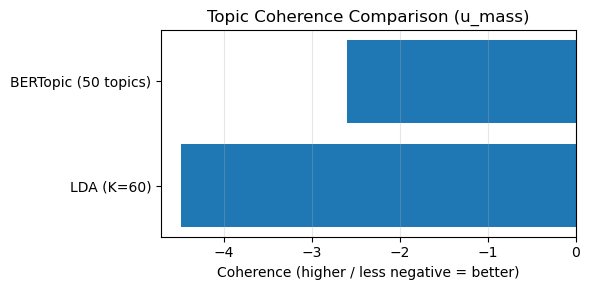

In [125]:

lda_umass = -4.492    # LDA best (K=60) from your baseline sweep
bert_umass = -2.603   # From your latest BERTopic coherence

comp = pd.DataFrame({
    "Model": ["LDA (K=60)", "BERTopic (50 topics)"],
    "Coherence (u_mass)": [lda_umass, bert_umass]
})

# Relative improvement (less negative is better)
abs_gain = bert_umass - lda_umass
rel_gain = abs_gain / abs(abs(lda_umass))  # ~+42%

print(f"Absolute gain: {abs_gain:.3f}  |  Relative improvement: {100*rel_gain:.1f}%")
display(comp)

# Simple horizontal bar chart
plt.figure(figsize=(6,3))
plt.barh(comp["Model"], comp["Coherence (u_mass)"])
plt.title("Topic Coherence Comparison (u_mass)")
plt.xlabel("Coherence (higher / less negative = better)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [127]:


bert_topics = [[w for w,_ in topic_model.get_topic(t)[:10]] 
               for t in sorted(topic_model.get_topics().keys()) if t >= 0]

def topic_diversity(topics):
    all_words = sum(topics, [])
    return len(set(all_words)) / max(1, len(all_words))


div_bert = topic_diversity(bert_topics)


print(f"BERTopic diversity: {div_bert:.3f}")


BERTopic diversity: 0.784


In [ ]:


# Reconstruct the same small table used before (manual input, no dependencies on any prior variables)
data = [
    {"topic": 23, "domain_label": "Black Hole Astrophysics", "slope": -0.001077, "p": 1.333886e-07, "sig": "***", "last_year_share": 0.004392},
    {"topic": 34, "domain_label": "Gamma-Ray Bursts & High-Energy Astrophysics", "slope": -0.001163, "p": 2.070475e-04, "sig": "***", "last_year_share": 0.005857},
    {"topic": 21, "domain_label": "Galaxy Formation & Cosmology", "slope": -0.001307, "p": 2.427601e-05, "sig": "***", "last_year_share": 0.013177},
    {"topic": 32, "domain_label": "Stellar Spectroscopy & Emission-Line Studies", "slope": -0.001426, "p": 2.362641e-07, "sig": "***", "last_year_share": 0.008785},
    {"topic": 29, "domain_label": "Theoretical Physics & String Theory", "slope": -0.001525, "p": 3.559782e-06, "sig": "***", "last_year_share": 0.010249},
    {"topic": 35, "domain_label": "Condensed Matter & Magnetism", "slope": -0.001757, "p": 4.023987e-08, "sig": "***", "last_year_share": 0.016105},
    {"topic": 24, "domain_label": "High-Energy Particle Collisions (Nuclear Physics)", "slope": -0.001921, "p": 1.704959e-10, "sig": "***", "last_year_share": 0.008785},
    {"topic": 20, "domain_label": "Quantum Phase Transitions & Lattice Models", "slope": -0.001923, "p": 2.520355e-08, "sig": "***", "last_year_share": 0.008785},
    {"topic": 17, "domain_label": "High-Energy Particle Physics (Higgs Studies)", "slope": -0.002092, "p": 1.821993e-07, "sig": "***", "last_year_share": 0.004392},
    {"topic": 13, "domain_label": "Quantum Chromodynamics (QCD) & Lattice Theory", "slope": -0.002308, "p": 4.233303e-08, "sig": "***", "last_year_share": 0.011713},
]
df = pd.DataFrame(data)

# Sort by slope (most negative to least negative)
df = df.sort_values("slope")


plt.figure(figsize=(12, 7))
y_pos = range(len(df))
bars = plt.barh(list(y_pos), df["slope"])  # negative values -> left-pointing bars
plt.yticks(list(y_pos), df["domain_label"])
plt.xlabel("Slope (per year)")
plt.title("Declining Research Topics (Manual Input, Domain Labels)")


for i, (slope, share, p, sig) in enumerate(zip(df["slope"], df["last_year_share"], df["p"], df["sig"])):
    # place text slightly to the right of the bar end
    x_text = slope - 0.00005  # a small offset further left (more negative)
    label = f"{slope:.4f} per yr | last_share={share:.3%} | p={p:.1e} {sig}"
    plt.text(x_text, i, label, va="center", ha="right", fontsize=9)

plt.tight_layout()
out_path = "declining_topics_manual_annotated.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")

#
